<a href="https://colab.research.google.com/github/steamulater/rap-snacks-v1/blob/main/boltz_validation_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rap-Snacks Boltz Validation v3 — native_ala_free

Folds two sequence buckets through Boltz-2 to validate designs from Run 4 (MPNN free design on native_ala backbones).

| Bucket | n | Label |
|--------|---|-------|
| native_ala_free MPNN designs | up to 600 (50 × 12 bars) | `native_ala_free` |
| Scrambled controls | 3 × 12 = 36 | `scrambled_naf` |

**Colour scheme** (consistent with v2):
- native_ala_free → green `#39d353`
- scrambled_naf → grey `#444455`

**Inputs from Drive** (`rap_snacks/inputs/`):
- `outputs/proteinmpnn_native_ala_free/filtered_results.csv`
- `data/phase2_candidates.csv`
- `data/aggregated_lines_v2_enriched.csv`

**Outputs to Drive** (`rap_snacks/results/`):
- `boltz_outputs_naf/` — raw Boltz PDBs for native_ala_free
- `boltz_outputs_naf_sc/` — raw Boltz PDBs for scrambled_naf
- `boltz_validation_v3_results.csv` — pLDDT / pTM / confidence per sequence
- `boltz_rmsd_v3.csv` — RMSD vs native_ala backbone per design
- `figures/fig_v3_*.png` — figures

---
## Cell 1 — Install

Run **once** per session. Auto-restarts the runtime after install.  
After restart, **skip this cell** and start from Cell 2.

In [ ]:
import subprocess, sys, os

try:
    import boltz  # noqa
    print('Boltz already installed — skip this cell.')
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-warn-conflicts', 'boltz'], check=True)
    print('Boltz installed. Restarting runtime...')
    os.kill(os.getpid(), 9)

---
## Cell 2 — Mount Drive + Check Inputs

In [3]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = Path('/content/drive/MyDrive/rap_snacks')
DRIVE_IN   = DRIVE_ROOT / 'inputs'
DRIVE_RES  = DRIVE_ROOT / 'results'
DRIVE_FIGS = DRIVE_RES  / 'figures'
CONTENT    = Path('/content/scratch')

for p in [DRIVE_IN, DRIVE_RES, DRIVE_FIGS, CONTENT]:
    p.mkdir(parents=True, exist_ok=True)

DATA        = DRIVE_IN / 'data'
MPNN_NAF    = DRIVE_IN / 'outputs' / 'proteinmpnn_native_ala_free' / 'filtered_results.csv'
BACKBONE_NA = DRIVE_IN / 'outputs' / 'proteinmpnn_native_ala_free' / 'pdbs'  # chain-fixed native_ala PDBs

checks = [
    DATA / 'aggregated_lines_v2_enriched.csv',
    DATA / 'phase2_candidates.csv',
    MPNN_NAF,
    BACKBONE_NA,
]
all_ok = True
for p in checks:
    status = '✅' if p.exists() else '❌ MISSING'
    if not p.exists(): all_ok = False
    print(f'{status}  {p.relative_to(DRIVE_ROOT)}')
if all_ok:
    print('\nAll inputs present — ready to run.')
else:
    print('\n⚠️  Upload missing files to Drive before continuing.')
    print('  Run: python analysis/09d_proteinmpnn_native_ala_free.py')
    print('  Then upload outputs/proteinmpnn_native_ala_free/ to Drive → rap_snacks/inputs/outputs/')

Mounted at /content/drive
✅  inputs/data/aggregated_lines_v2_enriched.csv
✅  inputs/data/phase2_candidates.csv
✅  inputs/outputs/proteinmpnn_native_ala_free/filtered_results.csv
✅  inputs/outputs/proteinmpnn_native_ala_free/pdbs

All inputs present — ready to run.


---
## Cell 3 — Config

In [4]:
import json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N       = 12
N_SCRAMBLES = 3      # scrambled seqs per bar (1 model each)
SEED        = 42
N_MODELS    = 5      # diffusion samples for native_ala_free
N_MODELS_SC = 1      # diffusion samples for scrambled_naf

VALID_AA = set('ACDEFGHIKLMNPQRSTVWY')

BOLTZ_IN    = CONTENT / 'boltz_inputs_naf'
BOLTZ_IN_SC = CONTENT / 'boltz_inputs_naf_sc'
BOLTZ_OUT   = CONTENT / 'boltz_outputs_naf'
BOLTZ_OUT_SC= CONTENT / 'boltz_outputs_naf_sc'

print(f'TOP_N={TOP_N}  N_MODELS={N_MODELS}  N_MODELS_SC={N_MODELS_SC}  N_SCRAMBLES={N_SCRAMBLES}')

TOP_N=12  N_MODELS=5  N_MODELS_SC=1  N_SCRAMBLES=3


---
## Cell 4 — Helpers

In [5]:
import random as _random

def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

def greedy_diverse(seqs, n=3):
    """Greedy max-min Hamming: pick n maximally spread sequences."""
    selected = [0]
    while len(selected) < min(n, len(seqs)):
        best, best_dist = -1, -1
        for i in range(len(seqs)):
            if i in selected:
                continue
            d = min(hamming(seqs[i], seqs[j]) for j in selected)
            if d > best_dist:
                best, best_dist = i, d
        selected.append(best)
    return [seqs[i] for i in selected]

def shuffle_seq(seq, seed=None):
    rng = _random.Random(seed)
    s = list(seq)
    rng.shuffle(s)
    return ''.join(s)

def write_boltz_yaml(name: str, seq: str, out_dir: Path) -> None:
    """Write a single-sequence Boltz YAML with msa: empty."""
    yaml = f"""version: 1
sequences:
  - protein:
      id: A
      sequence: {seq}
      msa: empty
"""
    (out_dir / f'{name}.yaml').write_text(yaml)

def parse_boltz_outputs(out_dir: Path, meta_df: pd.DataFrame) -> pd.DataFrame:
    """Parse pLDDT/pTM/confidence from Boltz confidence JSON files."""
    preds_dirs = list(out_dir.rglob('predictions'))
    if not preds_dirs:
        raise RuntimeError(f'No predictions/ dir under {out_dir}')
    preds = preds_dirs[0]

    rows = []
    for _, m in meta_df.iterrows():
        name    = m['name']
        seq_dir = preds / name
        jsons   = sorted(seq_dir.glob('confidence_*.json')) if seq_dir.exists() else []
        if not jsons:
            continue
        plddts, ptms, confs = [], [], []
        for jf in jsons:
            d = json.loads(jf.read_text())
            plddts.append(d.get('plddt', float('nan')))
            ptms.append(d.get('ptm',   float('nan')))
            confs.append(d.get('confidence_score', float('nan')))
        rows.append({
            'name':            name,
            'sequence':        m['sequence'],
            'bar_id':          m['bar_id'],
            'bucket':          m['bucket'],
            'detail':          m.get('detail', ''),
            'boltz_plddt':     float(np.nanmean(plddts)),
            'boltz_plddt_std': float(np.nanstd(plddts)),
            'boltz_ptm':       float(np.nanmean(ptms)),
            'boltz_confidence':float(np.nanmean(confs)),
            'n_models':        len(jsons),
        })
    return pd.DataFrame(rows)

def compute_rmsd(pdb1: Path, pdb2: Path) -> float | None:
    """Cα RMSD between two PDBs via BioPython Kabsch superposition."""
    try:
        from Bio.PDB import PDBParser
        from Bio.PDB.Superimposer import Superimposer
        parser = PDBParser(QUIET=True)
        s1 = parser.get_structure('a', pdb1)
        s2 = parser.get_structure('b', pdb2)
        ca1 = [a for a in s1.get_atoms() if a.name == 'CA']
        ca2 = [a for a in s2.get_atoms() if a.name == 'CA']
        n = min(len(ca1), len(ca2))
        if n < 3:
            return None
        sup = Superimposer()
        sup.set_atoms(ca1[:n], ca2[:n])
        return float(sup.rms)
    except Exception:
        return None

print('Helpers defined.')

Helpers defined.


---
## Cell 5 — Build Boltz Inputs

Loads `native_ala_free` designs and generates `scrambled_naf` controls.

In [6]:
BOLTZ_IN.mkdir(parents=True, exist_ok=True)
BOLTZ_IN_SC.mkdir(parents=True, exist_ok=True)

candidates = pd.read_csv(DATA / 'phase2_candidates.csv').head(TOP_N)
bar_ids    = list(candidates['bar_id'])
naf_df     = pd.read_csv(MPNN_NAF)

meta_rows    = []
meta_rows_sc = []
random.seed(SEED)

for bar_id in bar_ids:
    # native_ala_free — all passing designs
    grp = naf_df[(naf_df['bar_id'] == bar_id) & (naf_df['passes'] == True)].reset_index(drop=True)
    if grp.empty:
        grp = naf_df[naf_df['bar_id'] == bar_id].reset_index(drop=True)
        print(f'  [WARN] {bar_id}: no passing designs — using all {len(grp)} sequences')

    for i, row in grp.iterrows():
        seq = str(row['sequence']).upper()
        if not set(seq) <= VALID_AA:
            continue
        name = f'{bar_id}_naf_{i:03d}'
        write_boltz_yaml(name, seq, BOLTZ_IN)
        meta_rows.append({
            'name': name, 'sequence': seq, 'bar_id': bar_id,
            'bucket': 'native_ala_free',
            'detail': f'esm_plddt={row.get("esm_plddt", "")}'
        })

    # scrambled_naf — 3 diverse scrambles of the best-pLDDT design
    best_seqs = (grp.sort_values('esm_plddt', ascending=False)['sequence']
                 .dropna().tolist() if 'esm_plddt' in grp.columns else grp['sequence'].tolist())
    for sc_i, sc_seq in enumerate(shuffle_seq(best_seqs[0], seed=SEED + sc_i) for sc_i in range(N_SCRAMBLES)):
        sc_seq = sc_seq.upper()
        if not set(sc_seq) <= VALID_AA:
            continue
        sc_name = f'{bar_id}_sc_naf_{sc_i}'
        write_boltz_yaml(sc_name, sc_seq, BOLTZ_IN_SC)
        meta_rows_sc.append({
            'name': sc_name, 'sequence': sc_seq, 'bar_id': bar_id,
            'bucket': 'scrambled_naf', 'detail': f'scramble_{sc_i}'
        })

meta_df    = pd.DataFrame(meta_rows)
meta_df_sc = pd.DataFrame(meta_rows_sc)

n_naf = len(list(BOLTZ_IN.glob('*.yaml')))
n_sc  = len(list(BOLTZ_IN_SC.glob('*.yaml')))
print(f'\nnative_ala_free YAMLs: {n_naf}')
print(f'scrambled_naf   YAMLs: {n_sc}')
print(f'\nExample native_ala_free sequences:')
for bar_id in bar_ids[:3]:
    row = meta_df[meta_df['bar_id'] == bar_id].iloc[0]
    print(f'  {bar_id}: {row["sequence"][:50]}...')


native_ala_free YAMLs: 589
scrambled_naf   YAMLs: 36

Example native_ala_free sequences:
  bar_6: GAEELSEEKIRARVEAEAEARTAAYVAAHGPADAEAFYAREMERLLTIYR...
  bar_32: LAAALAALRAAAAAAEAAAPATPAGAALAPLLAALRAALAAAGAAAAAYA...
  bar_3: MAAEEAAAAAAAAAAAAKAAARAALAAYDAAVAAGDEAGVCAIFEAMGWA...


---
## Cell 6 — Run Boltz

Pass 1: native_ala_free  (N_MODELS=5 diffusion samples each — ~2–3 hrs on A100)  
Pass 2: scrambled_naf    (N_MODELS_SC=1)

Both passes back up to Drive immediately.

In [9]:
import subprocess  # needed after runtime restart (Cell 1 is skipped)

for d in [BOLTZ_OUT, BOLTZ_OUT_SC]:
    if d.exists(): shutil.rmtree(d)
BOLTZ_OUT.mkdir(parents=True, exist_ok=True)
BOLTZ_OUT_SC.mkdir(parents=True, exist_ok=True)

# Pass 1: native_ala_free
cmd1 = ['boltz', 'predict', str(BOLTZ_IN),
        '--out_dir', str(BOLTZ_OUT),
        '--diffusion_samples', str(N_MODELS),
        '--output_format', 'pdb',
        '--no_kernels', '--override']
print('Pass 1/2:', ' '.join(cmd1))
r1 = subprocess.run(cmd1, capture_output=False, text=True)
if r1.returncode != 0:
    print(f'[ERROR] Pass 1 failed (exit {r1.returncode})')
else:
    print('Pass 1 complete. Backing up to Drive...')
    drive_out1 = DRIVE_RES / 'boltz_outputs_naf'
    if drive_out1.exists(): shutil.rmtree(drive_out1)
    shutil.copytree(BOLTZ_OUT, drive_out1)
    print(f'Backed up → {sum(1 for _ in drive_out1.rglob("*.pdb"))} PDBs')

# Pass 2: scrambled_naf
cmd2 = ['boltz', 'predict', str(BOLTZ_IN_SC),
        '--out_dir', str(BOLTZ_OUT_SC),
        '--diffusion_samples', str(N_MODELS_SC),
        '--output_format', 'pdb',
        '--no_kernels', '--override']
print('Pass 2/2:', ' '.join(cmd2))
r2 = subprocess.run(cmd2, capture_output=False, text=True)
if r2.returncode != 0:
    print(f'[ERROR] Pass 2 failed (exit {r2.returncode})')
else:
    print('Pass 2 complete. Backing up to Drive...')
    drive_out2 = DRIVE_RES / 'boltz_outputs_naf_sc'
    if drive_out2.exists(): shutil.rmtree(drive_out2)
    shutil.copytree(BOLTZ_OUT_SC, drive_out2)
    print(f'Backed up → {sum(1 for _ in drive_out2.rglob("*.pdb"))} PDBs')

Pass 1/2: boltz predict /content/scratch/boltz_inputs_naf --out_dir /content/scratch/boltz_outputs_naf --diffusion_samples 5 --output_format pdb --no_kernels --override
Pass 1 complete. Backing up to Drive...
Backed up → 2945 PDBs
Pass 2/2: boltz predict /content/scratch/boltz_inputs_naf_sc --out_dir /content/scratch/boltz_outputs_naf_sc --diffusion_samples 1 --output_format pdb --no_kernels --override
Pass 2 complete. Backing up to Drive...
Backed up → 36 PDBs


---
## Cell 7 — Parse Results

Restores from Drive if scratch was wiped.

In [7]:
# Restore from Drive if scratch empty
for (out_dir, drive_key) in [(BOLTZ_OUT, 'boltz_outputs_naf'), (BOLTZ_OUT_SC, 'boltz_outputs_naf_sc')]:
    if not out_dir.exists() or not any(out_dir.rglob('*.pdb')):
        src = DRIVE_RES / drive_key
        if src.exists():
            print(f'Restoring {drive_key} from Drive...')
            shutil.copytree(src, out_dir, dirs_exist_ok=True)
            print(f'  {sum(1 for _ in out_dir.rglob("*.pdb"))} PDBs restored')
        else:
            print(f'[WARN] {drive_key} not on Drive — run Cell 6 first')

df1 = parse_boltz_outputs(BOLTZ_OUT,    meta_df)
df2 = parse_boltz_outputs(BOLTZ_OUT_SC, meta_df_sc)
results = pd.concat([df1, df2], ignore_index=True)

RESULTS_CSV = DRIVE_RES / 'boltz_validation_v3_results.csv'
results.to_csv(RESULTS_CSV, index=False)
print(f'Saved {len(results)} predictions → {RESULTS_CSV}')

print('\n--- pLDDT by bucket ---')
for bucket, grp in results.groupby('bucket'):
    print(f'  {bucket:20s}  n={len(grp):4d}  mean={grp["boltz_plddt"].mean():.3f}  sd={grp["boltz_plddt"].std():.3f}')

Restoring boltz_outputs_naf from Drive...


KeyboardInterrupt: 

### **Alternate #7 in the case when runtime disconnected**

In [8]:
  # Parse directly from Drive — no copy to scratch needed
  import json
  import numpy as np
  import pandas as pd
  from pathlib import Path

  def parse_from_drive(drive_out_dir, meta_df):
      """Parse Boltz confidence JSONs directly from Drive path."""
      preds_dirs = list(drive_out_dir.rglob('predictions'))
      if not preds_dirs:
          raise RuntimeError(f'No predictions/ dir under {drive_out_dir}')
      preds = preds_dirs[0]
      print(f'Predictions dir: {preds}  ({sum(1 for _ in preds.rglob("confidence_*.json"))} JSON files)')

      rows = []
      for _, m in meta_df.iterrows():
          name    = m['name']
          seq_dir = preds / name
          jsons   = sorted(seq_dir.glob('confidence_*.json')) if seq_dir.exists() else []
          if not jsons:
              continue
          plddts, ptms, confs = [], [], []
          for jf in jsons:
              d = json.loads(jf.read_text())
              plddts.append(d.get('plddt', float('nan')))
              ptms.append(d.get('ptm',   float('nan')))
              confs.append(d.get('confidence_score', float('nan')))
          rows.append({
              'name':            name,
              'sequence':        m['sequence'],
              'bar_id':          m['bar_id'],
              'bucket':          m['bucket'],
              'detail':          m.get('detail', ''),
              'boltz_plddt':     float(np.nanmean(plddts)),
              'boltz_plddt_std': float(np.nanstd(plddts)),
              'boltz_ptm':       float(np.nanmean(ptms)),
              'boltz_confidence':float(np.nanmean(confs)),
              'n_models':        len(jsons),
          })
      return pd.DataFrame(rows)

  # Parse directly from Drive — skip the scratch restore entirely
  df1 = parse_from_drive(DRIVE_RES / 'boltz_outputs_naf',    meta_df)
  df2 = parse_from_drive(DRIVE_RES / 'boltz_outputs_naf_sc', meta_df_sc)
  results = pd.concat([df1, df2], ignore_index=True)

  RESULTS_CSV = DRIVE_RES / 'boltz_validation_v3_results.csv'
  results.to_csv(RESULTS_CSV, index=False)
  print(f'Saved {len(results)} predictions → {RESULTS_CSV}')

  print('\n--- pLDDT by bucket ---')
  for bucket, grp in results.groupby('bucket'):
      print(f'  {bucket:22s}  n={len(grp):4d}  mean={grp["boltz_plddt"].mean():.3f}  sd={grp["boltz_plddt"].std():.3f}')

Predictions dir: /content/drive/MyDrive/rap_snacks/results/boltz_outputs_naf/boltz_results_boltz_inputs_naf/predictions  (2945 JSON files)


/tmp/ipykernel_6648/634230244.py:34: RuntimeWarning: Mean of empty slice
  'boltz_plddt':     float(np.nanmean(plddts)),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Predictions dir: /content/drive/MyDrive/rap_snacks/results/boltz_outputs_naf_sc/boltz_results_boltz_inputs_naf_sc/predictions  (36 JSON files)
Saved 625 predictions → /content/drive/MyDrive/rap_snacks/results/boltz_validation_v3_results.csv

--- pLDDT by bucket ---
  native_ala_free         n= 589  mean=nan  sd=nan
  scrambled_naf           n=  36  mean=nan  sd=nan


In [10]:
  import json
  import numpy as np
  import pandas as pd
  from pathlib import Path

  def parse_from_drive_v2(drive_out_dir, meta_df):
      preds_dirs = list(drive_out_dir.rglob('predictions'))
      if not preds_dirs:
          raise RuntimeError(f'No predictions/ dir under {drive_out_dir}')
      preds = preds_dirs[0]
      print(f'Predictions dir: {preds}  ({sum(1 for _ in preds.rglob("confidence_*.json"))} JSON files)')

      rows = []
      for _, m in meta_df.iterrows():
          name    = m['name']
          seq_dir = preds / name
          jsons   = sorted(seq_dir.glob('confidence_*.json')) if seq_dir.exists() else []
          if not jsons:
              continue
          plddts, ptms, confs = [], [], []
          for jf in jsons:
              d = json.loads(jf.read_text())
              plddts.append(d.get('complex_plddt', float('nan')))   # ← fixed key
              ptms.append(d.get('ptm',             float('nan')))
              confs.append(d.get('confidence_score', float('nan')))
          rows.append({
              'name':            name,
              'sequence':        m['sequence'],
              'bar_id':          m['bar_id'],
              'bucket':          m['bucket'],
              'detail':          m.get('detail', ''),
              'boltz_plddt':     float(np.nanmean(plddts)),
              'boltz_plddt_std': float(np.nanstd(plddts)),
              'boltz_ptm':       float(np.nanmean(ptms)),
              'boltz_confidence':float(np.nanmean(confs)),
              'n_models':        len(jsons),
          })
      return pd.DataFrame(rows)

  df1 = parse_from_drive_v2(DRIVE_RES / 'boltz_outputs_naf',    meta_df)
  df2 = parse_from_drive_v2(DRIVE_RES / 'boltz_outputs_naf_sc', meta_df_sc)
  results = pd.concat([df1, df2], ignore_index=True)

  RESULTS_CSV = DRIVE_RES / 'boltz_validation_v3_results.csv'
  results.to_csv(RESULTS_CSV, index=False)
  print(f'Saved {len(results)} predictions → {RESULTS_CSV}')

  print('\n--- pLDDT by bucket ---')
  for bucket, grp in results.groupby('bucket'):
      print(f'  {bucket:22s}  n={len(grp):4d}  mean={grp["boltz_plddt"].mean():.3f}  sd={grp["boltz_plddt"].std():.3f}')

Predictions dir: /content/drive/MyDrive/rap_snacks/results/boltz_outputs_naf/boltz_results_boltz_inputs_naf/predictions  (2945 JSON files)
Predictions dir: /content/drive/MyDrive/rap_snacks/results/boltz_outputs_naf_sc/boltz_results_boltz_inputs_naf_sc/predictions  (36 JSON files)
Saved 625 predictions → /content/drive/MyDrive/rap_snacks/results/boltz_validation_v3_results.csv

--- pLDDT by bucket ---
  native_ala_free         n= 589  mean=0.806  sd=0.140
  scrambled_naf           n=  36  mean=0.561  sd=0.134


---
## Cell 8 — pLDDT Figures

Fig H: strip plot per bar — native_ala_free vs scrambled_naf vs v2 buckets for context  
Fig I: violin — native_ala_free vs all v2 buckets (cross-run comparison)

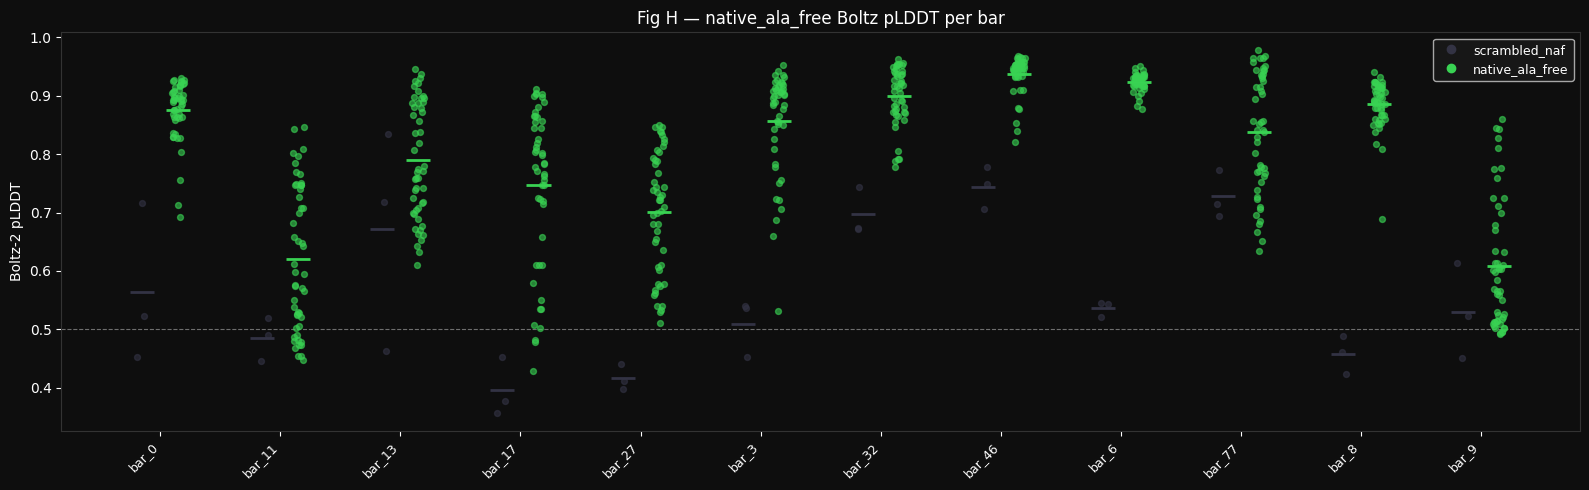

Fig H saved


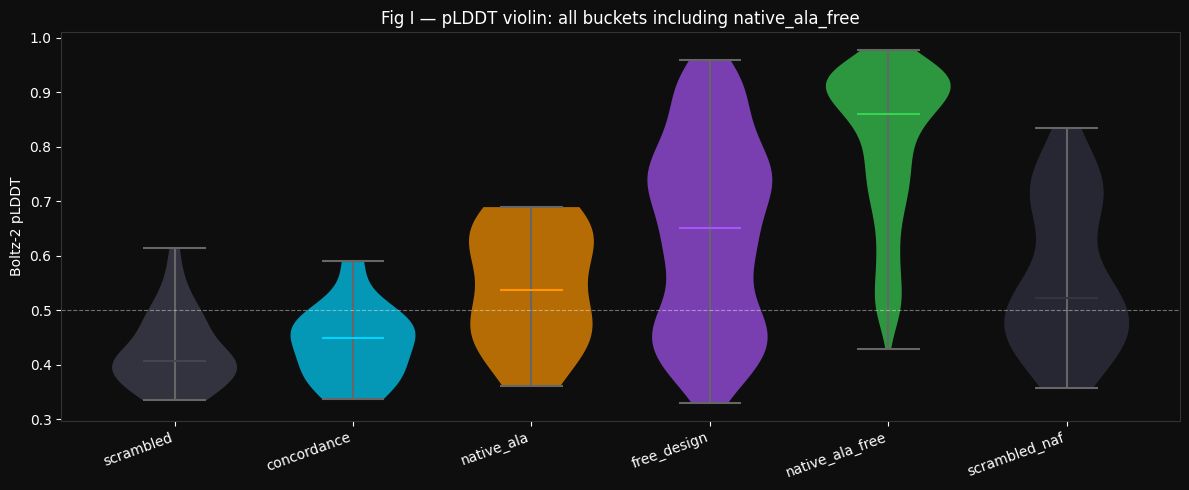

Fig I saved


In [11]:
DARK_BG = '#0e0e0e'
COLORS  = {
    'concordance':    '#00d4ff',
    'native_ala':     '#ff9500',
    'free_design':    '#a855f7',
    'scrambled':      '#444455',
    'native_ala_free':'#39d353',
    'scrambled_naf':  '#333344',
}

# ── Fig H: strip plot per bar ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

bar_ids_s = sorted(results['bar_id'].unique())
x_map     = {b: i for i, b in enumerate(bar_ids_s)}
buckets_h = ['scrambled_naf', 'native_ala_free']

for bucket in buckets_h:
    grp = results[results['bucket'] == bucket]
    for bar_id, sub in grp.groupby('bar_id'):
        xi = x_map[bar_id]
        offset = {'scrambled_naf': -0.15, 'native_ala_free': 0.15}[bucket]
        jitter = np.random.uniform(-0.05, 0.05, len(sub))
        ax.scatter([xi + offset + j for j in jitter], sub['boltz_plddt'],
                   color=COLORS[bucket], alpha=0.6, s=18, zorder=3)
        ax.hlines(sub['boltz_plddt'].mean(), xi + offset - 0.1, xi + offset + 0.1,
                  colors=COLORS[bucket], linewidth=2, zorder=4)

ax.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xticks(range(len(bar_ids_s)))
ax.set_xticklabels(bar_ids_s, rotation=45, ha='right', fontsize=9, color='white')
ax.set_ylabel('Boltz-2 pLDDT', color='white')
ax.set_title('Fig H — native_ala_free Boltz pLDDT per bar', color='white', fontsize=12)
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#333')
handles = [plt.Line2D([0],[0],marker='o',color=COLORS[b],linestyle='',label=b) for b in buckets_h]
ax.legend(handles=handles, facecolor='#1a1a1a', labelcolor='white', fontsize=9)
plt.tight_layout()
fig_h = CONTENT / 'fig_v3_strip.png'
plt.savefig(fig_h, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
shutil.copy2(fig_h, DRIVE_FIGS / 'fig_v3_strip.png')
plt.show()
print('Fig H saved')

# ── Fig I: violin cross-run comparison ───────────────────────────────────
# Load v2 results for comparison if available
v2_csv = DRIVE_RES / 'boltz_validation_results.csv'
combined = results.copy()
if v2_csv.exists():
    v2 = pd.read_csv(v2_csv)
    combined = pd.concat([v2[['bar_id','bucket','boltz_plddt']], results[['bar_id','bucket','boltz_plddt']]], ignore_index=True)

order_i = ['scrambled', 'concordance', 'native_ala', 'free_design', 'native_ala_free', 'scrambled_naf']
order_i = [b for b in order_i if b in combined['bucket'].unique()]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
for xi, bucket in enumerate(order_i):
    sub = combined[combined['bucket'] == bucket]['boltz_plddt'].dropna()
    if sub.empty: continue
    parts = ax.violinplot([sub.values], positions=[xi], widths=0.7, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(COLORS.get(bucket, '#888'))
        pc.set_alpha(0.7)
    parts['cmedians'].set_colors(COLORS.get(bucket, '#888'))
    parts['cbars'].set_colors('#666')
    parts['cmins'].set_colors('#666')
    parts['cmaxes'].set_colors('#666')

ax.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xticks(range(len(order_i)))
ax.set_xticklabels(order_i, rotation=20, ha='right', fontsize=10, color='white')
ax.set_ylabel('Boltz-2 pLDDT', color='white')
ax.set_title('Fig I — pLDDT violin: all buckets including native_ala_free', color='white', fontsize=12)
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#333')
plt.tight_layout()
fig_i = CONTENT / 'fig_v3_violin.png'
plt.savefig(fig_i, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
shutil.copy2(fig_i, DRIVE_FIGS / 'fig_v3_violin.png')
plt.show()
print('Fig I saved')

---
## Cell 9 — RMSD Analysis

RMSD of each native_ala_free design vs the **native_ala backbone** (the input backbone for this run).  
Also: pairwise RMSD within native_ala_free designs per bar (structural diversity of designs).

Compare with v2 where free_design RMSD was measured vs the concordance backbone.

In [14]:
  # Fix Cell 9 — install BioPython + read PDBs from Drive
  !pip install -q biopython

  from Bio.PDB import PDBParser
  from Bio.PDB.Superimposer import Superimposer

  def compute_rmsd(pdb1, pdb2):
      try:
          parser = PDBParser(QUIET=True)
          s1 = parser.get_structure('a', pdb1)
          s2 = parser.get_structure('b', pdb2)
          ca1 = [a for a in s1.get_atoms() if a.name == 'CA']
          ca2 = [a for a in s2.get_atoms() if a.name == 'CA']
          n = min(len(ca1), len(ca2))
          if n < 3: return None
          sup = Superimposer()
          sup.set_atoms(ca1[:n], ca2[:n])
          return float(sup.rms)
      except Exception as e:
          return None

  # Read PDBs from Drive (not scratch — cleared on reconnect)
  preds = list((DRIVE_RES / 'boltz_outputs_naf').rglob('predictions'))[0]
  print(f'Predictions dir: {preds}')
  print(f'PDBs present: {sum(1 for _ in preds.rglob("*.pdb"))}')

  backbone_dir = BACKBONE_NA  # Drive path from Cell 2
  rmsd_rows = []

  bar_ids_r = sorted(results[results['bucket'] == 'native_ala_free']['bar_id'].unique())

  for bar_id in bar_ids_r:
      ref_pdb = backbone_dir / f'{bar_id}.pdb'
      if not ref_pdb.exists():
          print(f'  [SKIP] {bar_id} — backbone not found')
          continue

      grp = results[(results['bar_id'] == bar_id) & (results['bucket'] == 'native_ala_free')]
      naf_pdbs = []

      for _, row in grp.iterrows():
          name    = row['name']
          seq_dir = preds / name
          pdbs    = sorted(seq_dir.glob('*.pdb')) if seq_dir.exists() else []
          if not pdbs: continue
          query_pdb = pdbs[0]
          naf_pdbs.append(query_pdb)
          rmsd = compute_rmsd(ref_pdb, query_pdb)
          rmsd_rows.append({
              'bar_id': bar_id, 'name': name, 'bucket': 'native_ala_free',
              'ref_bucket': 'native_ala', 'rmsd_vs_backbone': rmsd,
          })

      for i, p1 in enumerate(naf_pdbs):
          for p2 in naf_pdbs[i+1:]:
              rmsd = compute_rmsd(p1, p2)
              rmsd_rows.append({
                  'bar_id': bar_id, 'name': f'{p1.stem}__vs__{p2.stem}',
                  'bucket': 'naf_pairwise', 'ref_bucket': 'native_ala_free',
                  'rmsd_vs_backbone': rmsd,
              })

  rmsd_df = pd.DataFrame(rmsd_rows)
  RMSD_CSV = DRIVE_RES / 'boltz_rmsd_v3.csv'
  rmsd_df.to_csv(RMSD_CSV, index=False)
  print(f'\nSaved {len(rmsd_df)} RMSD rows → {RMSD_CSV}')

  print('\n--- RMSD vs native_ala backbone by bar ---')
  vs_bb = rmsd_df[rmsd_df['bucket'] == 'native_ala_free'].dropna(subset=['rmsd_vs_backbone'])
  for bar_id, g in vs_bb.groupby('bar_id'):
      print(f'  {bar_id:8s}  n={len(g):3d}  mean={g["rmsd_vs_backbone"].mean():.2f}Å  sd={g["rmsd_vs_backbone"].std():.2f}Å')
  pw = rmsd_df[rmsd_df['bucket'] == 'naf_pairwise']['rmsd_vs_backbone'].dropna()
  if not pw.empty:
      print(f'\nPairwise RMSD: mean={pw.mean():.2f}Å  sd={pw.std():.2f}Å')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.2 MB/s eta 0:00:00
Predictions dir: /content/drive/MyDrive/rap_snacks/results/boltz_outputs_naf/boltz_results_boltz_inputs_naf/predictions
PDBs present: 2945

Saved 14757 RMSD rows → /content/drive/MyDrive/rap_snacks/results/boltz_rmsd_v3.csv

--- RMSD vs native_ala backbone by bar ---
  bar_0     n= 49  mean=1.35Å  sd=1.03Å
  bar_11    n= 50  mean=10.79Å  sd=5.32Å
  bar_13    n= 50  mean=2.12Å  sd=2.31Å
  bar_17    n= 49  mean=3.71Å  sd=3.62Å
  bar_27    n= 49  mean=5.34Å  sd=3.42Å
  bar_3     n= 47  mean=2.26Å  sd=2.70Å
  bar_32    n= 47  mean=1.80Å  sd=3.50Å
  bar_46    n= 48  mean=1.34Å  sd=0.33Å
  bar_6     n= 50  mean=1.22Å  sd=0.78Å
  bar_77    n= 50  mean=13.54Å  sd=13.25Å
  bar_8     n= 50  mean=1.51Å  sd=1.29Å
  bar_9     n= 50  mean=7.81Å  sd=3.52Å

Pairwise RMSD: mean=5.83Å  sd=7.16Å


---
## Cell 10 — RMSD Figures

Fig J: violin — RMSD vs native_ala backbone  
Fig K: per-bar RMSD strip (native_ala_free vs native_ala backbone)  
Fig L: pairwise RMSD histogram

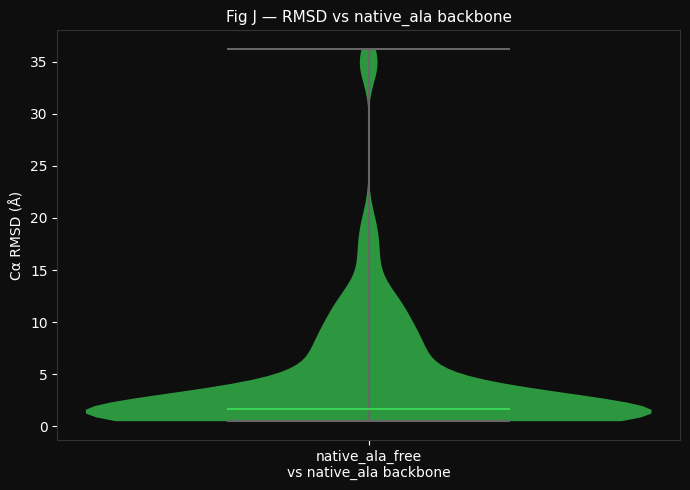

Fig J saved


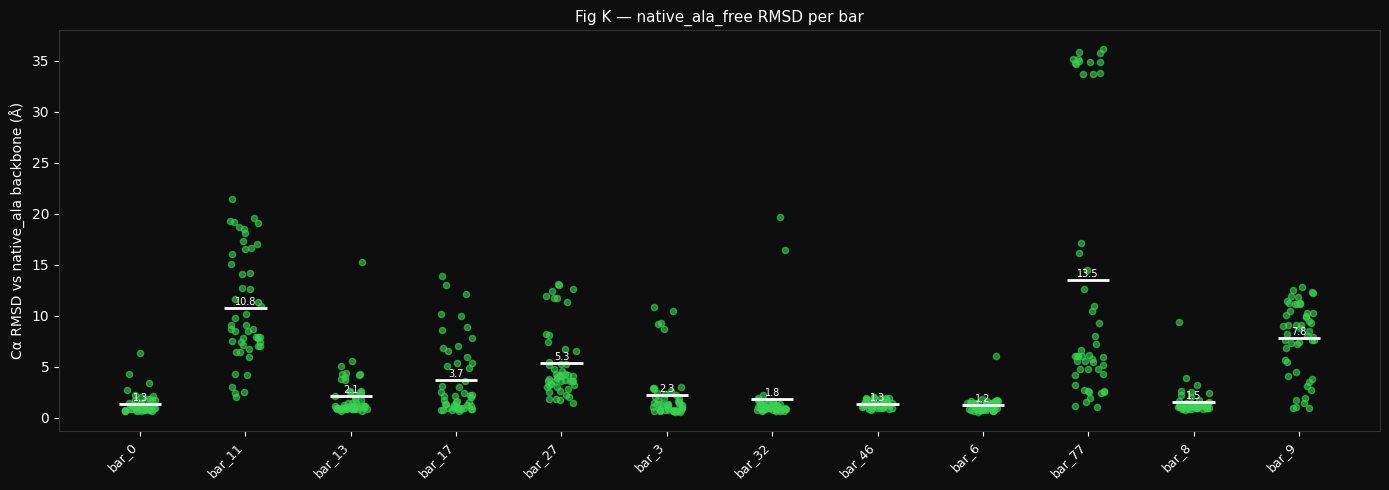

Fig K saved


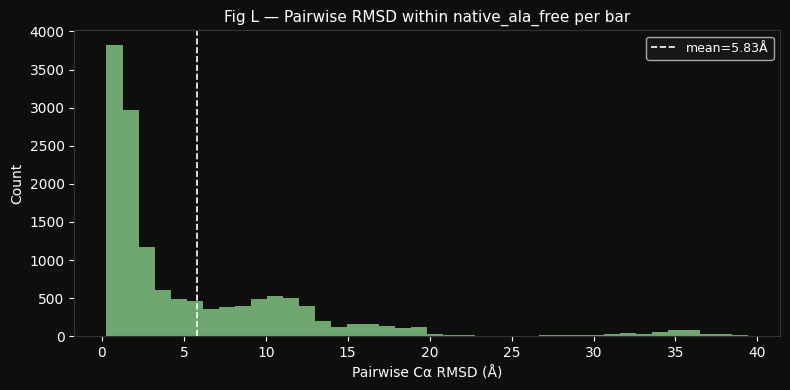

Fig L saved

All v3 figures saved to Drive: results/figures/fig_v3_*.png


In [15]:
RMSD_COLORS = {
    'native_ala_free': '#39d353',
    'naf_pairwise':    '#88cc88',
}

vs_bb = rmsd_df[rmsd_df['bucket'] == 'native_ala_free'].dropna(subset=['rmsd_vs_backbone'])
pw    = rmsd_df[rmsd_df['bucket'] == 'naf_pairwise'].dropna(subset=['rmsd_vs_backbone'])

# ── Fig J: violin RMSD vs native_ala backbone ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
parts = ax.violinplot([vs_bb['rmsd_vs_backbone'].values], positions=[0], widths=0.6, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor(RMSD_COLORS['native_ala_free']); pc.set_alpha(0.7)
parts['cmedians'].set_colors(RMSD_COLORS['native_ala_free'])
parts['cbars'].set_colors('#666'); parts['cmins'].set_colors('#666'); parts['cmaxes'].set_colors('#666')
ax.set_xticks([0]); ax.set_xticklabels(['native_ala_free\nvs native_ala backbone'], color='white')
ax.set_ylabel('Cα RMSD (Å)', color='white')
ax.set_title('Fig J — RMSD vs native_ala backbone', color='white', fontsize=11)
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#333')
plt.tight_layout()
fig_j = CONTENT / 'fig_v3_rmsd_violin.png'
plt.savefig(fig_j, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
shutil.copy2(fig_j, DRIVE_FIGS / 'fig_v3_rmsd_violin.png')
plt.show(); print('Fig J saved')

# ── Fig K: per-bar RMSD strip ────────────────────────────────────────────
bar_ids_k = sorted(vs_bb['bar_id'].unique())
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
for xi, bar_id in enumerate(bar_ids_k):
    sub = vs_bb[vs_bb['bar_id'] == bar_id]['rmsd_vs_backbone']
    jitter = np.random.uniform(-0.15, 0.15, len(sub))
    ax.scatter([xi + j for j in jitter], sub, color=RMSD_COLORS['native_ala_free'], alpha=0.6, s=20, zorder=3)
    ax.hlines(sub.mean(), xi - 0.2, xi + 0.2, colors='white', linewidth=2, zorder=4)
    ax.text(xi, sub.mean() + 0.3, f'{sub.mean():.1f}', color='white', ha='center', fontsize=7)
ax.set_xticks(range(len(bar_ids_k)))
ax.set_xticklabels(bar_ids_k, rotation=45, ha='right', fontsize=9, color='white')
ax.set_ylabel('Cα RMSD vs native_ala backbone (Å)', color='white')
ax.set_title('Fig K — native_ala_free RMSD per bar', color='white', fontsize=11)
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#333')
plt.tight_layout()
fig_k = CONTENT / 'fig_v3_rmsd_per_bar.png'
plt.savefig(fig_k, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
shutil.copy2(fig_k, DRIVE_FIGS / 'fig_v3_rmsd_per_bar.png')
plt.show(); print('Fig K saved')

# ── Fig L: pairwise RMSD histogram ───────────────────────────────────────
if not pw.empty:
    fig, ax = plt.subplots(figsize=(8, 4), facecolor=DARK_BG)
    ax.set_facecolor(DARK_BG)
    ax.hist(pw['rmsd_vs_backbone'], bins=40, color=RMSD_COLORS['naf_pairwise'], alpha=0.8, edgecolor='none')
    ax.axvline(pw['rmsd_vs_backbone'].mean(), color='white', linestyle='--', linewidth=1.2,
               label=f'mean={pw["rmsd_vs_backbone"].mean():.2f}Å')
    ax.set_xlabel('Pairwise Cα RMSD (Å)', color='white')
    ax.set_ylabel('Count', color='white')
    ax.set_title('Fig L — Pairwise RMSD within native_ala_free per bar', color='white', fontsize=11)
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#333')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    plt.tight_layout()
    fig_l = CONTENT / 'fig_v3_rmsd_pairwise.png'
    plt.savefig(fig_l, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
    shutil.copy2(fig_l, DRIVE_FIGS / 'fig_v3_rmsd_pairwise.png')
    plt.show(); print('Fig L saved')
else:
    print('[SKIP] No pairwise RMSD data')

print('\nAll v3 figures saved to Drive: results/figures/fig_v3_*.png')

---
## Cell 11 — Summary

Prints key numbers and highlights bars where native_ala_free outperforms free_design (v2).

Upload `boltz_validation_v3_results.csv` and `boltz_rmsd_v3.csv` to the repo  
(`outputs/boltz_validation/`) and commit.

In [16]:
print('=== Boltz Validation v3 Summary ===\n')
print(f'Total predictions: {len(results)}')

for bucket, grp in results.groupby('bucket'):
    print(f'  {bucket:22s}  n={len(grp):4d}  mean pLDDT={grp["boltz_plddt"].mean():.3f}  sd={grp["boltz_plddt"].std():.3f}')

# Per-bar: native_ala_free mean pLDDT
print('\n--- Per-bar native_ala_free pLDDT ---')
naf = results[results['bucket'] == 'native_ala_free']
for bar_id, g in naf.groupby('bar_id'):
    print(f'  {bar_id:8s}  n={len(g):3d}  mean={g["boltz_plddt"].mean():.3f}  max={g["boltz_plddt"].max():.3f}')

# Compare with v2 free_design if available
if v2_csv.exists():
    v2 = pd.read_csv(v2_csv)
    fd = v2[v2['bucket'] == 'free_design']
    print('\n--- native_ala_free vs free_design (v2) per bar ---')
    print(f'  {"bar":8s}  {"naf_mean":>9s}  {"fd_mean":>8s}  {"Δ":>6s}')
    for bar_id in sorted(naf['bar_id'].unique()):
        naf_mean = naf[naf['bar_id'] == bar_id]['boltz_plddt'].mean()
        fd_mean  = fd[fd['bar_id'] == bar_id]['boltz_plddt'].mean() if not fd[fd['bar_id'] == bar_id].empty else float('nan')
        delta    = naf_mean - fd_mean
        marker   = ' ↑' if delta > 0.02 else (' ↓' if delta < -0.02 else '')
        print(f'  {bar_id:8s}  {naf_mean:9.3f}  {fd_mean:8.3f}  {delta:+6.3f}{marker}')

print('\nDone. Download results CSVs from Drive and commit.')

=== Boltz Validation v3 Summary ===

Total predictions: 625
  native_ala_free         n= 589  mean pLDDT=0.806  sd=0.140
  scrambled_naf           n=  36  mean pLDDT=0.561  sd=0.134

--- Per-bar native_ala_free pLDDT ---
  bar_0     n= 49  mean=0.876  max=0.930
  bar_11    n= 50  mean=0.621  max=0.847
  bar_13    n= 50  mean=0.790  max=0.945
  bar_17    n= 49  mean=0.747  max=0.912
  bar_27    n= 49  mean=0.700  max=0.850
  bar_3     n= 47  mean=0.857  max=0.953
  bar_32    n= 47  mean=0.899  max=0.963
  bar_46    n= 48  mean=0.937  max=0.968
  bar_6     n= 50  mean=0.924  max=0.951
  bar_77    n= 50  mean=0.838  max=0.978
  bar_8     n= 50  mean=0.885  max=0.940
  bar_9     n= 50  mean=0.609  max=0.860

--- native_ala_free vs free_design (v2) per bar ---
  bar        naf_mean   fd_mean       Δ
  bar_0         0.876     0.460  +0.416 ↑
  bar_11        0.621     0.590  +0.031 ↑
  bar_13        0.790     0.723  +0.068 ↑
  bar_17        0.747     0.743  +0.004
  bar_27        0.700     0.

In [20]:
  #Cell A — Config + load CSV
  import json, shutil, subprocess
  import numpy as np
  import pandas as pd
  from pathlib import Path

  DRIVE_ROOT = Path('/content/drive/MyDrive/rap_snacks')
  DRIVE_RES  = DRIVE_ROOT / 'results'
  DRIVE_FIGS = DRIVE_RES / 'figures'
  CONTENT    = Path('/content/scratch')

  BOLTZ_IN  = CONTENT / 'boltz_inputs_sc_na'
  BOLTZ_OUT = CONTENT / 'boltz_outputs_sc_na'

  # Upload scrambled_na_esm.csv to Drive first, or load from wherever it landed
  SCRAMBLED_CSV = DRIVE_ROOT / 'inputs/outputs/bioreason/scrambled_na_esm.csv'

  sc_df = pd.read_csv(SCRAMBLED_CSV)
  print(f'Loaded {len(sc_df)} sequences')
  sc_df['scramble_idx'] = sc_df['name'].str.extract(r'_sc_na_(\d+)$').astype(int)
  print(sc_df.head(3).to_string(index=False))


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/rap_snacks/inputs/outputs/bioreason/scrambled_na_esm.csv'